# Flight Fare Price Project

In [26]:
# Import the Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_excel("C:\\Users\\yuvra\\Downloads\\Flight fare Price Data_Train (1).xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [28]:
# Display first 5 rows
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [29]:
# Check number of rows and columns
df.shape

(10683, 11)

In [30]:
# Check column names
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [31]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [32]:
# Check missing values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

# Data Cleaning

In [33]:
# Remove duplicate rows
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()

0

In [35]:
# Remove rows with missing values
df = df.dropna()

# Check missing values again
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [36]:
# Convert price into numeric format
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Price"]

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10462, dtype: int64

In [37]:
# Clean airline names
df["Airline"] = df["Airline"].str.strip().str.title()
df["Airline"] 

0             Indigo
1          Air India
2        Jet Airways
3             Indigo
4             Indigo
            ...     
10678       Air Asia
10679      Air India
10680    Jet Airways
10681        Vistara
10682      Air India
Name: Airline, Length: 10462, dtype: object

In [38]:
# Extract departure hour
df["Departure_Hour"] = df["Dep_Time"].str.split(":").str[0].astype(int)
df["Departure_Hour"]

0        22
1         5
2         9
3        18
4        16
         ..
10678    19
10679    20
10680     8
10681    11
10682    10
Name: Departure_Hour, Length: 10462, dtype: int32

In [39]:
# Extract duration hours
df["Duration_Hours"] = df["Duration"].str.extract(r"(\d+)").astype(float)
df["Duration_Hours"]

0         2.0
1         7.0
2        19.0
3         5.0
4         4.0
         ... 
10678     2.0
10679     2.0
10680     3.0
10681     2.0
10682     8.0
Name: Duration_Hours, Length: 10462, dtype: float64

In [40]:
# Convert date of journey
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"], dayfirst=True, errors="coerce")
df["Date_of_Journey"]

0       2019-03-24
1       2019-05-01
2       2019-06-09
3       2019-05-12
4       2019-03-01
           ...    
10678   2019-04-09
10679   2019-04-27
10680   2019-04-27
10681   2019-03-01
10682   2019-05-09
Name: Date_of_Journey, Length: 10462, dtype: datetime64[ns]

In [43]:
# Remove missing values
df = df.dropna()
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Departure_Hour,Duration_Hours
0,Indigo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,22,2.0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,7.0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,19.0
3,Indigo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,18,5.0
4,Indigo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,16,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,19,2.0
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,20,2.0
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,8,3.0
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,11,2.0


In [44]:
# Check missing values after cleaning
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
Departure_Hour     0
Duration_Hours     0
dtype: int64

In [45]:
# Check duplicate rows after cleaning
df.duplicated().sum()

0

In [46]:
# Display cleaned data
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Departure_Hour,Duration_Hours
0,Indigo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,22,2.0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,5,7.0
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,19.0
3,Indigo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,18,5.0
4,Indigo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,16,4.0


In [79]:
# Save cleaned data
df.to_excel("C:\\Users\\yuvra\\Downloads\\Flight fare Price Data_Train (1).xlsx")

# Exploratory Data Analysis:

In [53]:
# 1. Average price by airline:

airline_price = df.groupby("Airline")["Price"].mean().sort_values(ascending=False)
print(airline_price)
print("Highest average price:", airline_price.index[0])

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple Carriers Premium Economy    11418.846154
Multiple Carriers                    10902.678094
Air India                             9556.608028
Vistara Premium Economy               8962.333333
Vistara                               7801.355649
Goair                                 5861.056701
Indigo                                5668.469897
Air Asia                              5590.260188
Spicejet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64
Highest average price: Jet Airways Business


In [54]:
# 2. Compare non-stop and connecting flight prices:

df["Flight_Type"] = df["Total_Stops"].apply(
    lambda x: "Non-stop" if x == 0 else "Connecting"
)
flight_price = df.groupby("Flight_Type")["Price"].mean()
print(flight_price)

Flight_Type
Connecting    9026.790289
Name: Price, dtype: float64


In [55]:
# 3. Find the most expensive routes:

route_price = df.groupby(["Source", "Destination"])["Price"].mean().sort_values(ascending=False)
print(route_price.head(10))

Source    Destination
Banglore  New Delhi      12007.421225
Delhi     Cochin         10461.600690
Kolkata   Banglore        9143.083566
Banglore  Delhi           5143.918577
Mumbai    Hyderabad       5059.708752
Chennai   Kolkata         4789.892388
Name: Price, dtype: float64


In [57]:
# Compare average price for different flight durations:
df.groupby("Duration_Hours")["Price"].mean().head(10)

Duration_Hours
1.0      3932.809984
2.0      5058.476330
3.0      6229.212000
4.0      6645.630631
5.0      8979.272349
6.0     11496.370588
7.0     11537.531828
8.0     10860.728774
9.0     10889.238202
10.0    11284.005634
Name: Price, dtype: float64

In [52]:
# Find average price for each departure hour:
df.groupby("Departure_Hour")["Price"].mean().sort_values(ascending=False)

Departure_Hour
3     10474.625000
16    10330.783080
8     10073.923631
18    10043.981859
14     9816.409901
20     9683.838213
9      9559.092551
5      9480.309278
11     9296.739206
12     9251.573034
13     8998.725061
10     8870.728653
17     8710.355588
23     8487.338346
7      8485.902665
21     8450.296524
2      8419.974227
19     8344.700368
6      8252.195556
22     7765.975871
15     7687.410658
0      7615.075000
4      7266.520710
1      4354.621622
Name: Price, dtype: float64

In [58]:
# 5. Average price by departure hour:

df["Departure_Hour"] = df["Dep_Time"].str.split(":").str[0].astype(int)
departure_price = df.groupby("Departure_Hour")["Price"].mean().sort_values(ascending=False)
print(departure_price)
print("Highest price departure hour:", departure_price.index[0])

Departure_Hour
3     10474.625000
16    10330.783080
8     10073.923631
18    10043.981859
14     9816.409901
20     9683.838213
9      9559.092551
5      9480.309278
11     9296.739206
12     9251.573034
13     8998.725061
10     8870.728653
17     8710.355588
23     8487.338346
7      8485.902665
21     8450.296524
2      8419.974227
19     8344.700368
6      8252.195556
22     7765.975871
15     7687.410658
0      7615.075000
4      7266.520710
1      4354.621622
Name: Price, dtype: float64
Highest price departure hour: 3


# Data Visualizations

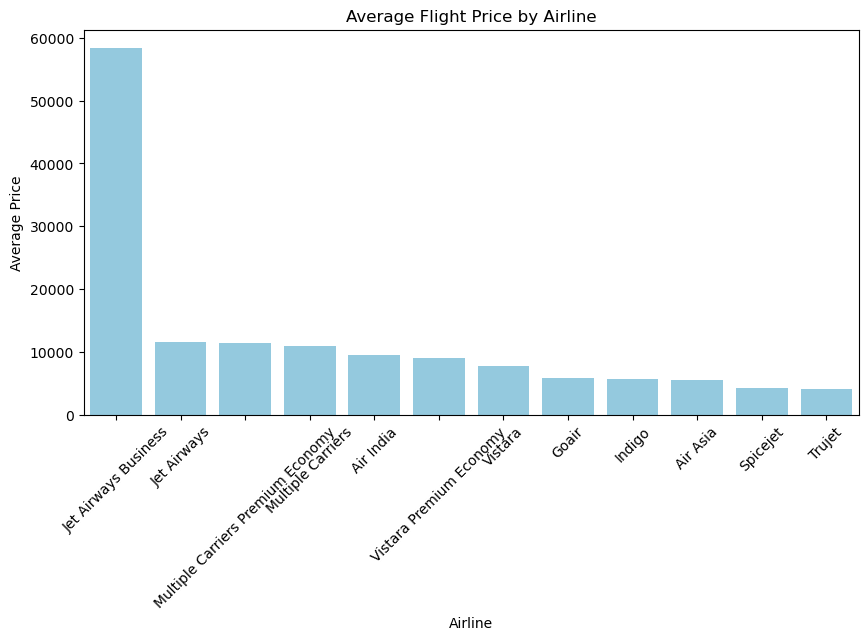

In [60]:
# 1. Average price by airline
data = df.groupby("Airline")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=data.index, y=data.values, color="skyblue")
plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

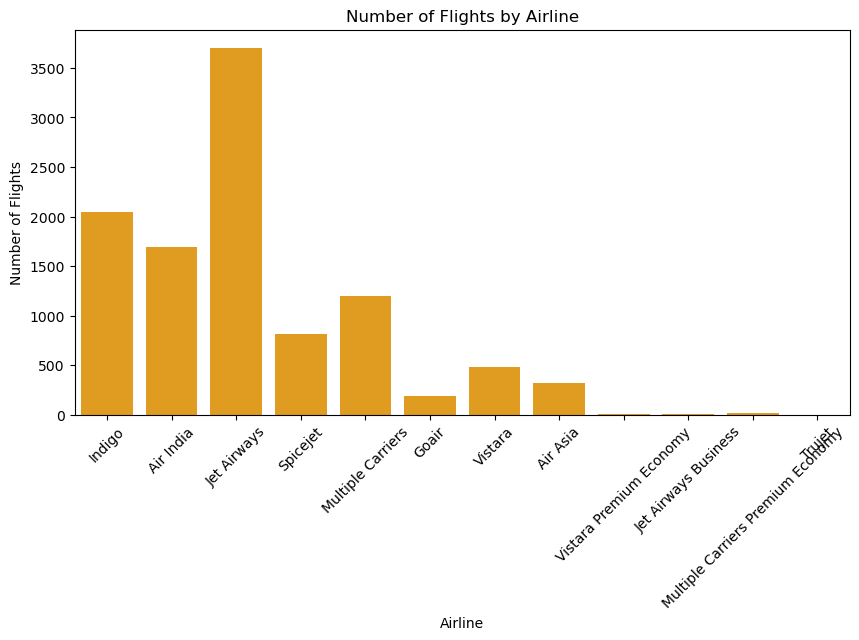

In [61]:
# 2. Number of flights by airline:

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Airline", color="orange")
plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

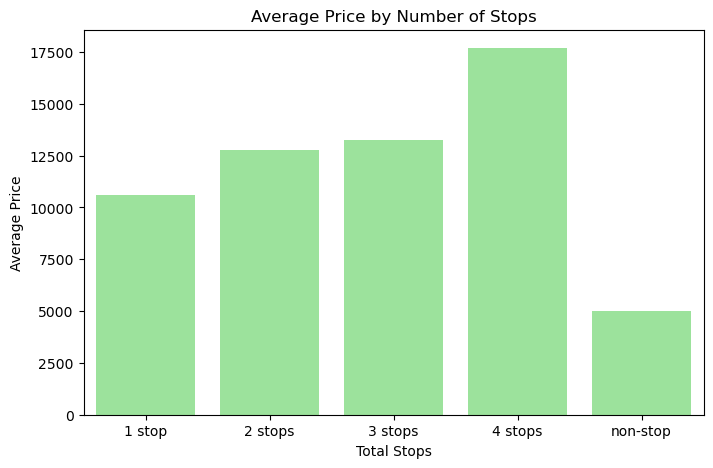

In [62]:
# 3. Average price by stops
data = df.groupby("Total_Stops")["Price"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=data.index, y=data.values, color="lightgreen")
plt.title("Average Price by Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Average Price")
plt.show()

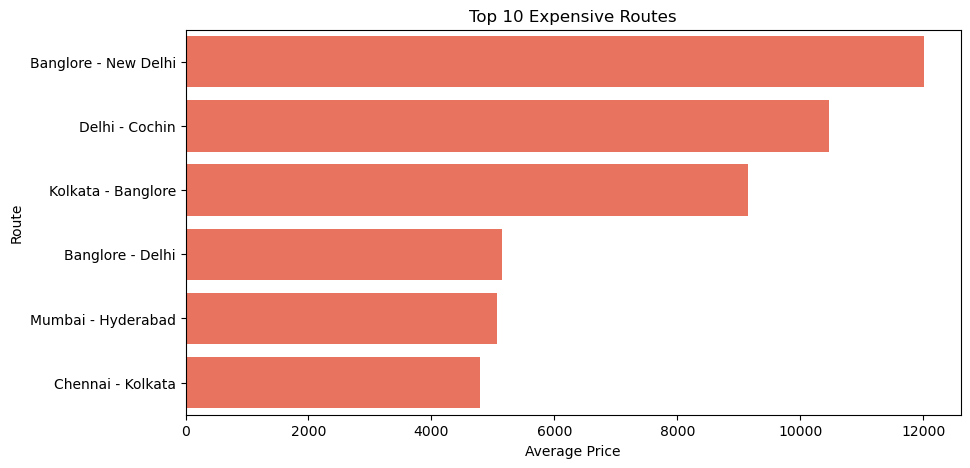

In [63]:
# 4. Top 10 expensive routes
data = df.groupby(["Source", "Destination"])["Price"].mean().sort_values(ascending=False).head(10)

data.index = [str(x[0]) + " - " + str(x[1]) for x in data.index]

plt.figure(figsize=(10,5))
sns.barplot(x=data.values, y=data.index, color="tomato")
plt.title("Top 10 Expensive Routes")
plt.xlabel("Average Price")
plt.ylabel("Route")
plt.show()

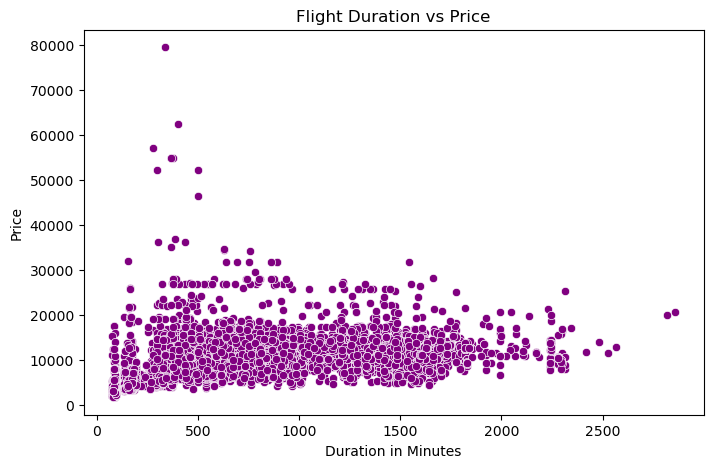

In [64]:
# 5. Duration vs price
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Duration_Total_Minutes", y="Price", color="purple")
plt.title("Flight Duration vs Price")
plt.xlabel("Duration in Minutes")
plt.ylabel("Price")
plt.show()

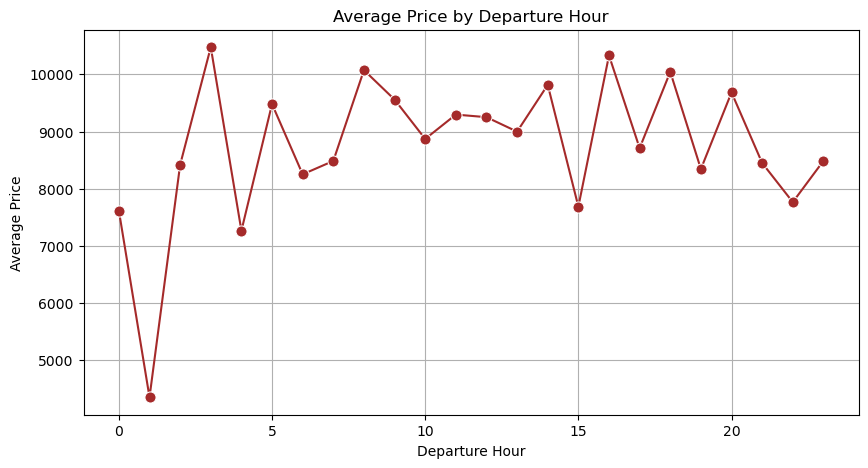

In [77]:
# 6. Average price by departure hour
data = df.groupby("Departure_Hour")["Price"].mean()

plt.figure(figsize=(10,5))
sns.lineplot(
    x=data.index,
    y=data.values,
    color="brown",
    marker="o",
    markersize=8
)

plt.title("Average Price by Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Average Price")
plt.grid()
plt.show()

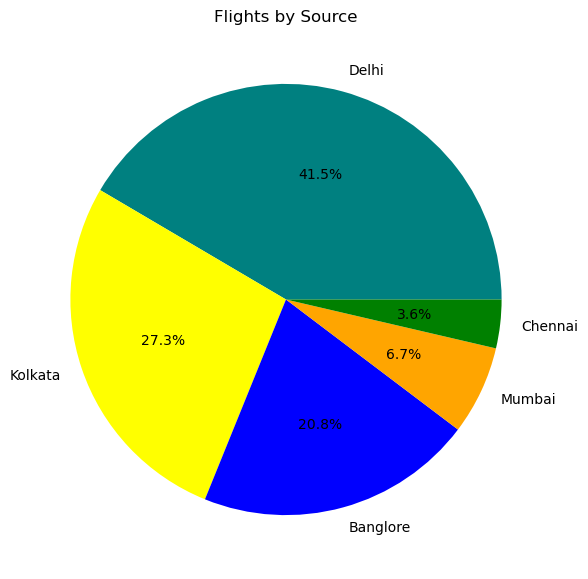

In [68]:
# 7. Flights by source
data = df["Source"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(data.values, labels=data.index, autopct="%1.1f%%", colors=["teal", "yellow", "blue", "orange", "green"] * len(data))
plt.title("Flights by Source")
plt.show()

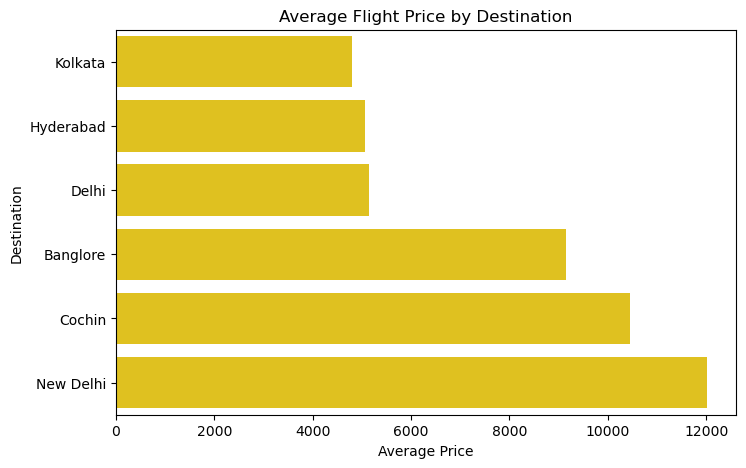

In [69]:
# 8. Average price by destination
data = df.groupby("Destination")["Price"].mean().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=data.values, y=data.index, color="gold")
plt.title("Average Flight Price by Destination")
plt.xlabel("Average Price")
plt.ylabel("Destination")
plt.show()

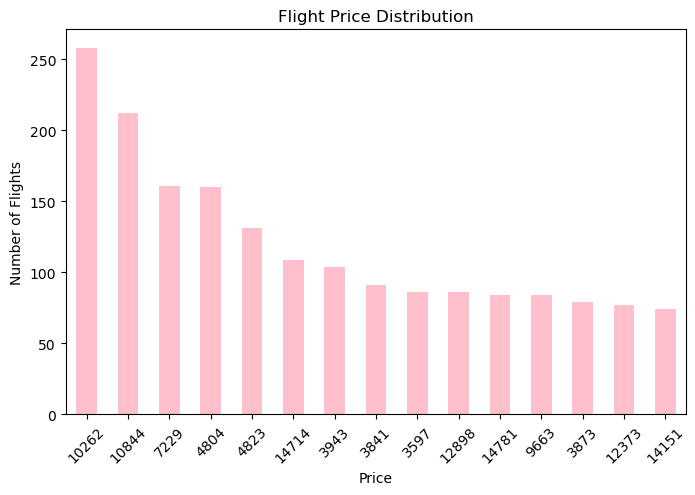

In [75]:
# 9. Flight price distribution
price = df["Price"].value_counts().head(15)

plt.figure(figsize=(8,5))
price.plot(kind="bar", color="pink")
plt.title("Flight Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

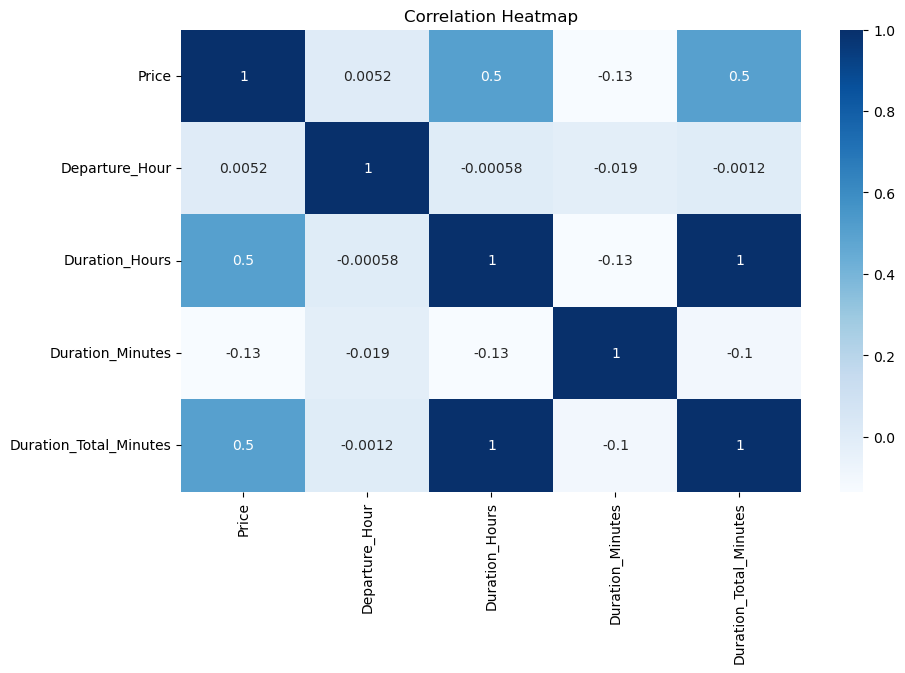

In [71]:
# 10. Correlation between numerical columns
plt.figure(figsize=(10,6))
numbers = df.select_dtypes(include="number")

sns.heatmap(numbers.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()